In [159]:
from hikyuu.interactive import *

#创建一个从2022年4月1日开始的账户，初始资金100万元
my_tm = crtTM(date = Datetime(200204010000), init_cash = 1000000, cost_func=TC_FixedA(commission=0.0001, lowest_commission=5.0))
#不做仓位管理，全仓买进卖出
my_mm = MM_Nothing()

#回测时间设定
query = Query(Datetime(200204010000), Datetime(202604010000))

#回测标的限定
s = sm['sh000300']

In [160]:
# 买卖策略
def TurtleSG(self, k):
     n1 = self.get_param("n1")
     n2 = self.get_param("n2")
     c = CLOSE(k)
     h = REF(HHV(c, n1), 1) #前n日高点
     L = REF(LLV(c, n2), 1) #前n日低点
     for i in range(h.discard, len(k)):
         if (c[i] >= h[i]):
             self._add_buy_signal(k[i].datetime)
         elif (c[i] <= L[i]):
             self._add_sell_signal(k[i].datetime)

my_sg = crtSG(TurtleSG, {'n1': 20, 'n2': 10}, 'TurtleSG')

In [161]:
def SKDJDivergenceSG(self, k):
    """
    SKDJ背离策略 - 使用KDJ函数替代STOCH
    参数说明:
    n: KDJ周期参数，默认9
    m1: K值平滑参数，默认3
    m2: D值平滑参数，默认3
    oversold: 超卖阈值，默认20
    overbought: 超买阈值，默认80
    lookback: 背离检测回溯周期，默认20
    """
    # 获取参数
    n = self.get_param("n")
    m = self.get_param("m")
    oversold = self.get_param("oversold")
    overbought = self.get_param("overbought")
    lookback = self.get_param("lookback")
    
    # 计算KDJ指标（替代STOCH）
    # KDJ函数返回三个值：k, d, j
    # 其中k就是STOCH的%K线，d就是STOCH的%D线
    # kdj_k, kdj_d, kdj_j = KDJ(k, n, m1, m2)
    
    # 获取价格数据
    c = CLOSE(k)
    l = LOW(k)
    h = HIGH(k)

    c = CLOSE(k)
    l = LOW(k)
    h = HIGH(k)
    lowv = LLV(l, n)
    highv = HHV(h, n)
    rsv = (c - lowv) / (highv - lowv) * 100
    rsv_slow = EMA(rsv, m)
    skdj_k = EMA(rsv_slow, m)






    
    # 确保有足够的数据进行计算
    if len(c) < lookback + 5 or len(skdj_k) < lookback + 5:
        return
    
    # 遍历每个K线
    for i in range(max(lookback, 5), len(k)):
        # 计算当前KDJ值（作为SKDJ使用）
        k_current = skdj_k[i]
        # d_current = kdj_d[i]
        
        # 检测底背离买入信号
        buy_signal = False
        
        # 条件1: SKDJ处于超卖区
        if k_current < oversold:
            # 条件2: 寻找近期的价格低点和KDJ低点
            # 查找最近的价格低点
            price_min_idx = i
            k_min_idx = i
            
            for j in range(1, lookback):
                idx = i - j
                if l[idx] < l[price_min_idx]:
                    price_min_idx = idx
                if skdj_k[idx] < skdj_k[k_min_idx]:
                    k_min_idx = idx
            
            # 条件3: 价格创新低但KDJ没有创新低
            if (price_min_idx == i and  # 当前价格是最低点
                k_min_idx != i and  # KDJ最低点不是当前点
                skdj_k[k_min_idx] < oversold and  # KDJ低点在超卖区
                l[i] < l[k_min_idx] and  # 价格创新低
                skdj_k[i] > kdj_k[k_min_idx]):  # KDJ没有创新低
                
                # 确认条件: 价格开始反弹
                if c[i] > c[i-1] and c[i-1] > c[i-2]:
                    buy_signal = True
        
        # 检测顶背离卖出信号
        sell_signal = False
        
        # 条件1: KDJ处于超买区
        if k_current > overbought:
            # 条件2: 寻找近期的价格高点和KDJ高点
            # 查找最近的价格高点
            price_max_idx = i
            k_max_idx = i
            
            for j in range(1, lookback):
                idx = i - j
                if h[idx] > h[price_max_idx]:
                    price_max_idx = idx
                if skdj_k[idx] > skdj_k[k_max_idx]:
                    k_max_idx = idx
            
            # 条件3: 价格创新高但KDJ没有创新高
            if (price_max_idx == i and  # 当前价格是最高点
                k_max_idx != i and  # KDJ最高点不是当前点
                skdj_k[k_max_idx] > overbought and  # KDJ高点在超买区
                h[i] > h[k_max_idx] and  # 价格创新高
                skdj_k[i] < skdj_k[k_max_idx]):  # KDJ没有创新高
                
                # 确认条件: 价格开始回落
                if c[i] < c[i-1] and c[i-1] < c[i-2]:
                    sell_signal = True
        
        # 根据信号执行操作
        if buy_signal:
            self._add_buy_signal(k[i].datetime)
        elif sell_signal:
            self._add_sell_signal(k[i].datetime)


# 创建策略实例
my_sg = crtSG(SKDJDivergenceSG, 
              {'n': 9, 'm': 3, 'oversold': 50, 'overbought': 80, 'lookback': 20}, 
              'SKDJ背离策略')

In [162]:
#进行回测

sys = SYS_Simple(tm = my_tm, mm = my_mm, sg = simple_sg)
sys.run(s, query)

<Axes: title={'center': '账户(SYS) 累积收益率'}>

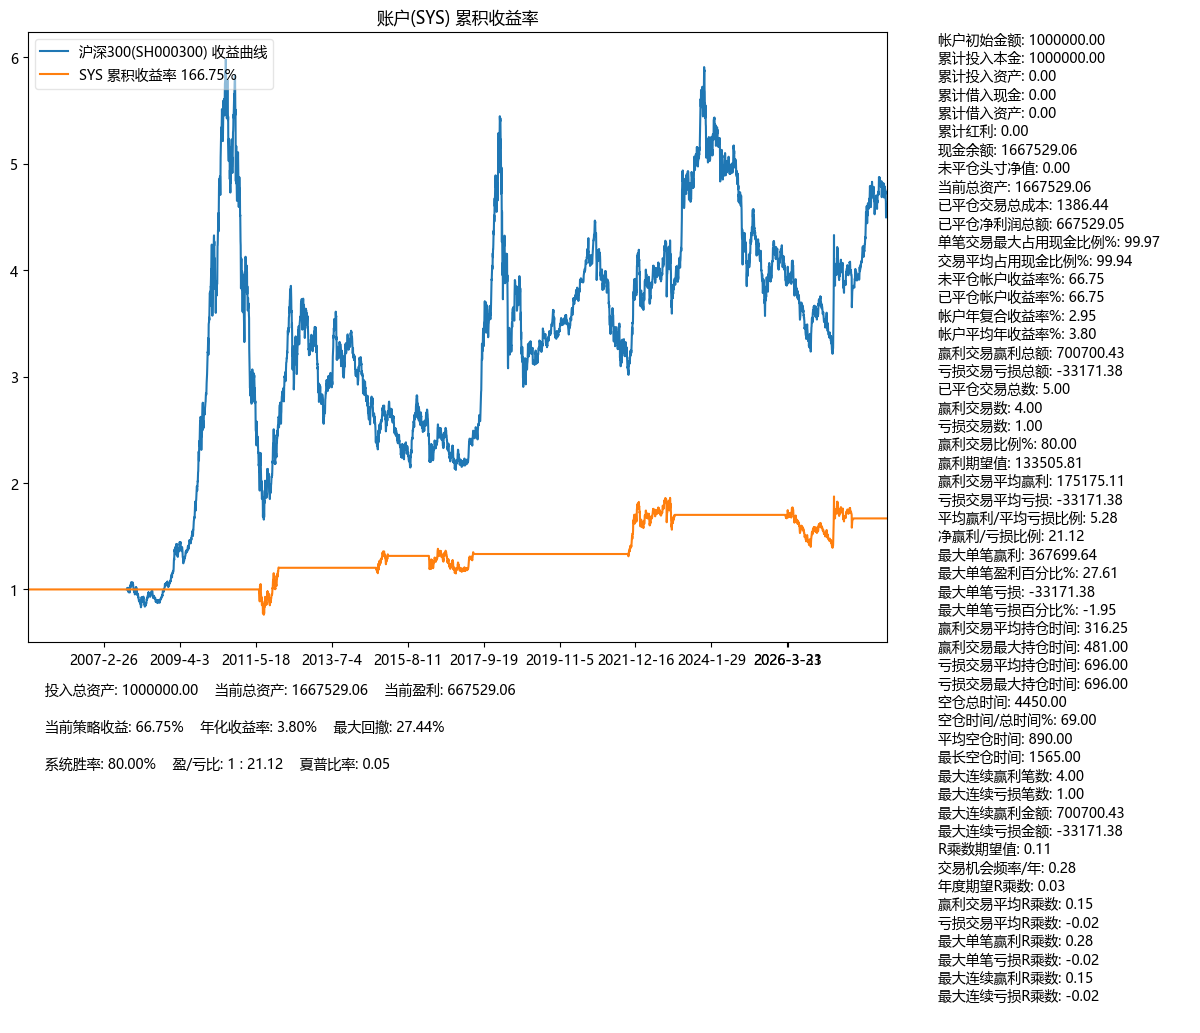

In [163]:
sys.performance()

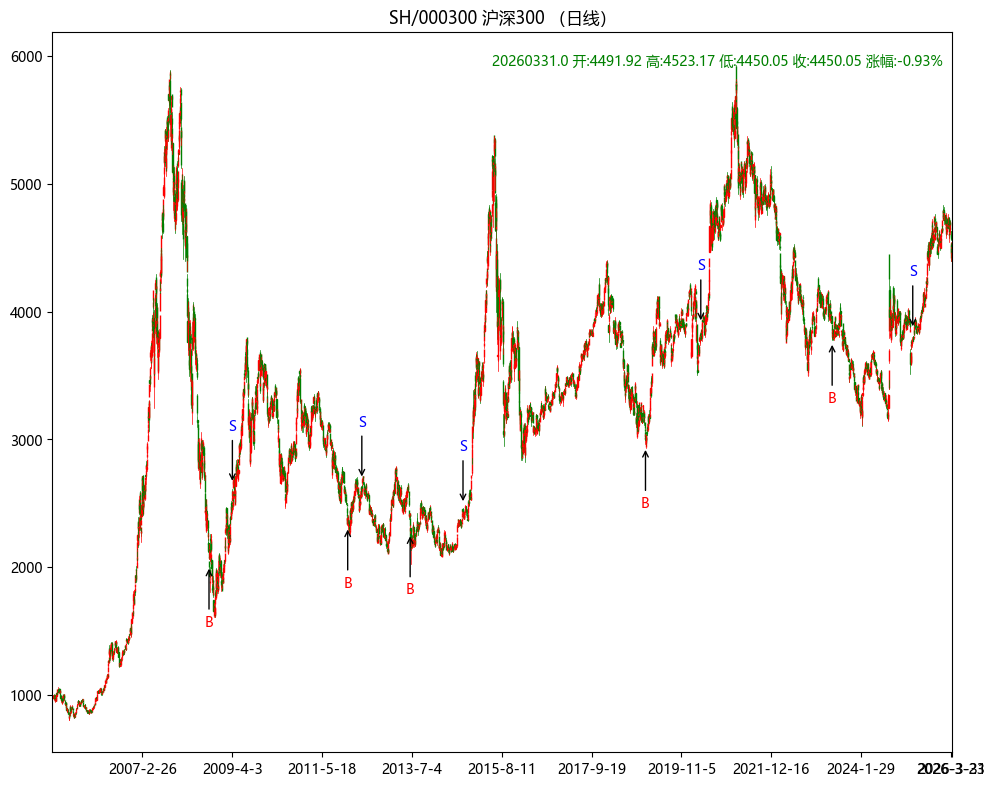

2026-04-23 00:00:04.543 [HKU-I] - start reload ... (StockManager.cpp:434)
2026-04-23 00:00:04.547 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-04-23 00:00:04.550 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-04-23 00:00:04.553 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-04-23 00:00:06.844 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-04-23 00:00:07.109 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-04-23 00:00:07.238 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-04-23 00:00:07.260 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-23 00:00:07.262 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-23 00:00:07.264 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-23 00:00:07.266 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-23 00:00:07.268 [HKU-I] - 2.72 秒数据加载完毕. (StockManager.cpp:198)


In [164]:
sys.plot()
# MA(CLOSE(sys.to), 20).plot(new=False)

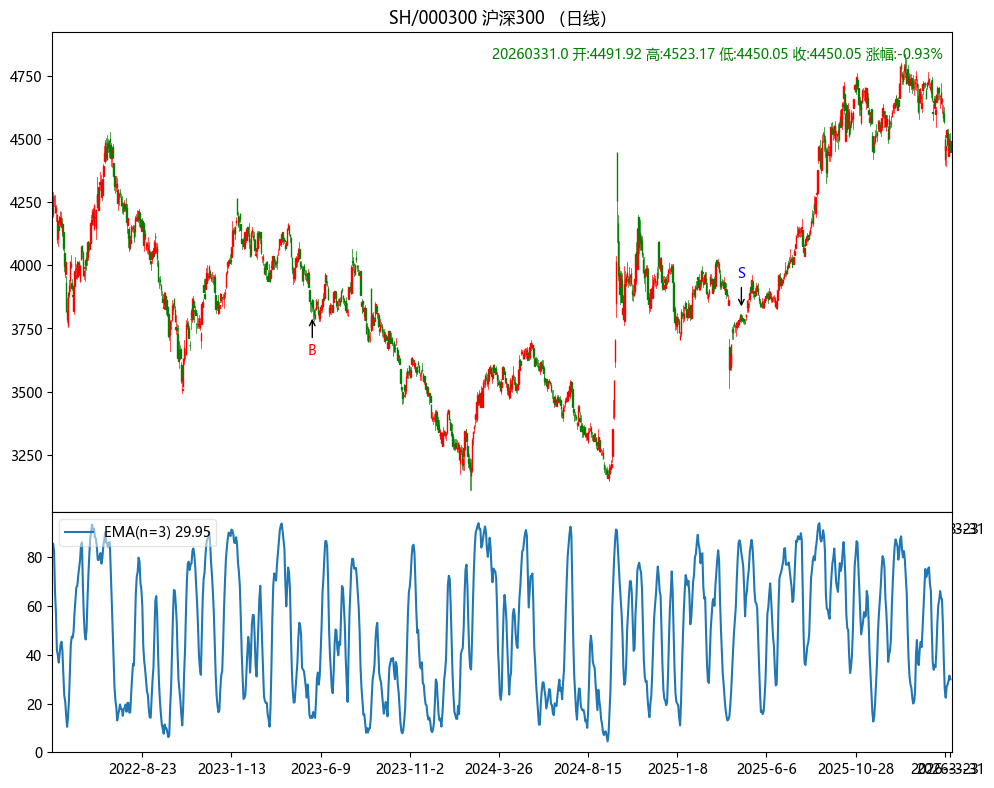

In [118]:

ax1,ax2 = create_figure(2)
sys.plot(axes=ax1)

#在第二个坐标轴中绘制艾尔德力度指标
# skdj_k = MA(KDJ(s.get_kdata(query))[0],n=3)
# skdj_k.plot(axes=ax2, legend_on=True)

n=9 
m=3
k =  s.get_kdata(query)
c = CLOSE(k)
l = LOW(k)
h = HIGH(k)
lowv = LLV(l, n)
highv = HHV(h, n)
rsv = (c - lowv) / (highv - lowv) * 100
rsv_slow = EMA(rsv, m)
skdj_k = EMA(rsv_slow, m)

skdj_k.plot(axes=ax2, legend_on=True)

In [107]:
skdj_k

Indicator{
  name: EMA
  size: 967
  discard: 0
  stock: 
  result sets: 1
  params: params[n(int): 3, ]
  is python object: False
  formula: EMA(EMA(CLOSE - LLV(LOW) / HHV(HIGH) - LLV(LOW) * CVAL(CLOSE - LLV(LOW) / HHV(HIGH) - LLV(LOW))))
  values0: [85.5751, 82.5132, 65.8465, ..., 29.307, 31.4757, 29.951]
}

In [34]:
import pandas as pd
def calTotal(blk, q):
    per = Performance()
    s_name = []
    s_code = []
    x = []
    for stk in blk:
        sys.run(stk, q)
        per.statistics(my_tm, Datetime.now())
        s_name.append(stk.name)
        s_code.append(stk.market_code)
        x.append(per["当前总资产"])
    return pd.DataFrame({'代码': s_code, '股票': s_name, '当前总资产': x})

%time data = calTotal(blocka, query)

2026-04-22 16:58:03.348 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-22 16:58:03.349 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-22 16:58:03.350 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
2026-04-22 16:58:03.350 [HKU-W] - Over stock.maxTradeNumber(1000000), will use maxTradeNumber (MoneyManagerBase.cpp:129)
CPU times: total: 11 s
Wall time: 11 s


In [36]:
data

,代码,股票,当前总资产
0,SH603235,天新药业,665075.40
1,SH603976,正川股份,817050.62
2,SH605299,舒华体育,971220.23
3,SH603266,天龙股份,1232851.99
4,BJ920508,殷图网联,1699926.29
...,...,...,...
3501,BJ920961,创远信科,1606363.28
3502,BJ920964,润农节水,2522887.30
3503,BJ920970,大禹生物,2859539.64
3504,BJ920978,开特股份,3066581.26


In [40]:
for stk in blocka:
    print(stk)

Stock(SH, 603235, 天新药业, A股, 1, 2022-07-12 00:00:00, +infinity)
Stock(SH, 603976, 正川股份, A股, 1, 2017-08-22 00:00:00, +infinity)
Stock(SH, 605299, 舒华体育, A股, 1, 2020-12-15 00:00:00, +infinity)
Stock(SH, 603266, 天龙股份, A股, 1, 2017-01-10 00:00:00, +infinity)
Stock(BJ, 920508, 殷图网联, 北交所, 1, 2020-07-27 00:00:00, +infinity)
Stock(SH, 600959, 江苏有线, A股, 1, 2015-04-28 00:00:00, +infinity)
Stock(SH, 601101, 昊华能源, A股, 1, 2010-03-31 00:00:00, +infinity)
Stock(SH, 601519, 大智慧, A股, 1, 2011-01-28 00:00:00, +infinity)
Stock(BJ, 920914, 远航精密, 北交所, 1, 2022-11-11 00:00:00, +infinity)
Stock(SH, 605186, 健麾信息, A股, 1, 2020-12-22 00:00:00, +infinity)
Stock(SH, 601216, 君正集团, A股, 1, 2011-02-22 00:00:00, +infinity)
Stock(SH, 603236, 移远通信, A股, 1, 2019-07-16 00:00:00, +infinity)
Stock(SH, 601518, 吉林高速, A股, 1, 2010-03-19 00:00:00, +infinity)
Stock(BJ, 920124, 南特科技, 北交所, 1, 2025-11-27 00:00:00, +infinity)
Stock(SH, 600405, 动力源, A股, 1, 2004-04-01 00:00:00, +infinity)
Stock(SH, 603237, 五芳斋, A股, 1, 2022-08-31 00:00:00, +in

In [128]:
def find_extreme_points_zigzag(k, reversal_percent=0.05):
    """
    使用ZigZag算法识别显著的高低点
    
    参数:
    k: K线数据
    reversal_percent: 反转百分比，默认5%
    
    返回:
    (high_points, low_points) 元组
    """
    high = HIGH(k)
    low = LOW(k)
    
    points = []  # 存储所有极值点
    direction = 0  # 方向：1上升，-1下降
    last_extreme = None
    last_extreme_idx = 0
    
    n = len(k)
    
    for i in range(1, n):
        if last_extreme is None:
            # 初始化第一个点
            last_extreme = high[i]  # 使用最高价作为起始参考
            last_extreme_idx = i
            points.append({
                'index': i,
                'price': high[i],
                'type': 'high',
                'datetime': k[i].datetime
            })
            continue
        
        current_high = high[i]
        current_low = low[i]
        
        if direction >= 0:  # 当前趋势为上升或无趋势
            # 检查是否出现更高的高点
            if current_high > last_extreme * (1 + reversal_percent/100):
                # 记录新的高点
                points.append({
                    'index': i,
                    'price': current_high,
                    'type': 'high',
                    'datetime': k[i].datetime
                })
                last_extreme = current_high
                last_extreme_idx = i
                direction = 1
            # 检查是否出现足够的下跌
            elif current_low < last_extreme * (1 - reversal_percent/100):
                points.append({
                    'index': i,
                    'price': current_low,
                    'type': 'low',
                    'datetime': k[i].datetime
                })
                last_extreme = current_low
                last_extreme_idx = i
                direction = -1
        
        else:  # 当前趋势为下降
            # 检查是否出现更低的低点
            if current_low < last_extreme * (1 - reversal_percent/100):
                points.append({
                    'index': i,
                    'price': current_low,
                    'type': 'low',
                    'datetime': k[i].datetime
                })
                last_extreme = current_low
                last_extreme_idx = i
                direction = -1
            # 检查是否出现足够的上涨
            elif current_high > last_extreme * (1 + reversal_percent/100):
                points.append({
                    'index': i,
                    'price': current_high,
                    'type': 'high',
                    'datetime': k[i].datetime
                })
                last_extreme = current_high
                last_extreme_idx = i
                direction = 1
    
    # 分离高点和低点
    high_points = [p for p in points if p['type'] == 'high']
    low_points = [p for p in points if p['type'] == 'low']
    
    return high_points, low_points

In [139]:
# 获取K线数据
stock = sm['sh000300']
k = stock.get_kdata(Query(-600))

def find_phase_low_points_with_confirmation(k, window=5, min_depth=0.01):
    """
    增强版本：带确认条件的阶段低点寻找
    
    参数：
    k: K线数据
    window: 时间窗口大小
    min_depth: 最小深度（相对周围价格的百分比）
    
    返回：
    包含阶段低点信息的列表
    """
    # 获取价格序列
    low_prices = LOW(k)
    high_prices = HIGH(k)
    close_prices = CLOSE(k)
    
    n = len(k)
    phase_lows = []
    
    for i in range(window, n - window):
        # 获取窗口
        start_idx = i - window
        end_idx = i + window + 1
        
        # 当前最低价
        current_low = low_prices[i]
        
        # 条件1：是窗口内的最低点
        window_lows = low_prices[start_idx:end_idx]
        if current_low > min(window_lows):
            continue
        
        # 条件2：检查唯一性（严格小于窗口内其他所有最低价）
        is_unique_min = True
        for j in range(start_idx, end_idx):
            if j != i and low_prices[j] <= current_low:
                is_unique_min = False
                break
        
        if not is_unique_min:
            continue
        
        # 条件3：最小深度要求
        # 计算窗口内除当前点外的平均最低价
        other_lows = [low_prices[j] for j in range(start_idx, end_idx) if j != i]
        avg_other_lows = sum(other_lows) / len(other_lows) if other_lows else current_low
        
        # 计算深度
        depth = (avg_other_lows - current_low) / avg_other_lows
        if depth < min_depth:
            continue
        
        # 条件4：价格形态确认（可选）
        # 检查是否形成V形底：前几日下跌，后几日上涨
        is_v_shape = True
        for offset in range(1, 4):  # 检查前后3日
            if i - offset >= 0 and i + offset < n:
                # 前几日应该下跌或持平
                if close_prices[i-offset] < current_low:
                    is_v_shape = False
                    break
                # 后几日应该上涨
                if close_prices[i+offset] < current_low:
                    is_v_shape = False
                    break
        
        # 记录符合条件的阶段低点
        phase_lows.append({
            'index': i,
            'date': k[i].datetime,
            'low_price': float(current_low),
            'avg_surrounding': float(avg_other_lows),
            'depth_percent': float(depth * 100),
            'is_v_shape': is_v_shape,
            'window_size': 2 * window + 1
        })
    
    return phase_lows

find_phase_low_points_with_confirmation(k)

[{'index': 37,
  'date': Datetime(2023,12,21,0,0,0,0,0),
  'low_price': 3283.9900000000002,
  'avg_surrounding': 3321.88,
  'depth_percent': 1.1406191674593866,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 56,
  'date': Datetime(2024,1,18,0,0,0,0,0),
  'low_price': 3171.63,
  'avg_surrounding': 3239.066,
  'depth_percent': 2.0819581941213827,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 67,
  'date': Datetime(2024,2,2,0,0,0,0,0),
  'low_price': 3108.35,
  'avg_surrounding': 3254.302,
  'depth_percent': 4.484894149344474,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 100,
  'date': Datetime(2024,3,28,0,0,0,0,0),
  'low_price': 3489.39,
  'avg_surrounding': 3537.6870000000004,
  'depth_percent': 1.3652140508756279,
  'is_v_shape': True,
  'window_size': 11},
 {'index': 109,
  'date': Datetime(2024,4,12,0,0,0,0,0),
  'low_price': 3470.06,
  'avg_surrounding': 3514.0550000000003,
  'depth_percent': 1.2519724364018305,
  'is_v_shape': True,
  'window_size': 11},